# LightGBM Modeling

## Data Loading

In [2]:
# Necessary imports
import pandas as pd

df = pd.read_parquet("../../data/training_table.parquet")
df.head()

,datetime_ept,month,day_of_week,hour_of_day,is_weekend,is_holiday,temperature_2m_selected,wind_speed_10m_selected,cloud_cover_selected,forecast_load_mw,...,lagged_solar_percentage_7,lagged_wind_percentage_1,lagged_wind_percentage_3,lagged_wind_percentage_7,lagged_storage_percentage_1,lagged_storage_percentage_3,lagged_storage_percentage_7,rolling_rt_mean,rolling_rt_stddev,total_lmp_rt
0,2026-05-07 11:00:00,5,4,11,0,0,11.8,9.9,100.0,14140,...,0.055,0.035,0.088,0.044,0.0,0.0,0.001,61.173503,91.512419,29.327974
1,2026-05-07 14:00:00,5,4,14,0,0,11.3,10.2,100.0,14061,...,0.057,0.025,0.090,0.069,0.0,0.0,0.001,78.573187,133.916377,25.634580
2,2026-05-07 23:00:00,5,4,23,0,0,9.8,12.9,73.0,13305,...,0.000,0.017,0.091,0.037,0.0,0.0,0.000,116.480542,114.414232,31.662833
3,2026-05-08 06:00:00,5,5,6,0,0,6.3,4.7,0.0,14006,...,0.000,0.019,0.070,0.020,0.0,0.0,0.000,88.922437,56.848159,59.293955
4,2026-05-08 15:00:00,5,5,15,0,0,18.7,20.9,13.0,13853,...,0.118,0.043,0.089,0.046,0.0,0.0,0.000,118.401468,143.234859,82.302426


## EDA

In [3]:
# Data sanity checks
print(df.shape)
print(df.dtypes.value_counts())
print(df['datetime_ept'].min(), df['datetime_ept'].max())
print(df['is_holiday'].sum())

(20815, 76)
float64           69
int64              4
int32              2
datetime64[us]     1
Name: count, dtype: int64
2024-01-27 08:00:00 2026-06-30 23:00:00
599


In [4]:
# Checking for nulls
df.isna().any().any()

np.False_

In [5]:
# Target variable summary
print(df['total_lmp_rt'].describe())

count    20815.000000
mean        58.680457
std         98.349540
min        -41.839513
25%         24.109437
50%         33.924041
75%         52.448136
max       2014.424132
Name: total_lmp_rt, dtype: float64


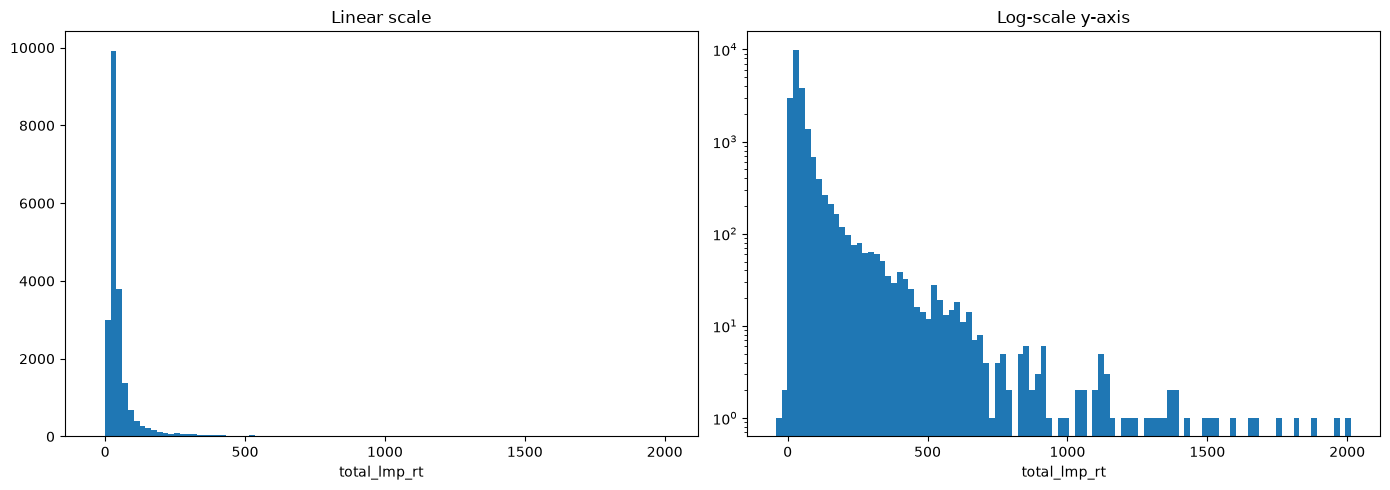

In [6]:
# Analyzing target distribution
import matplotlib.pyplot as plt

target = df['total_lmp_rt']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(target, bins=100)
axes[0].set_title("Linear scale")
axes[0].set_xlabel("total_lmp_rt")

axes[1].hist(target, bins=100)
axes[1].set_yscale('log')
axes[1].set_title("Log-scale y-axis")
axes[1].set_xlabel("total_lmp_rt")

plt.tight_layout()
plt.show()


In [7]:
import numpy as np

# Using an arcsin h transformation because it is heavily right-skewed and contains negatives

df['arcsinh_total_lmp_rt'] = np.arcsinh(df['total_lmp_rt'])


In [8]:
# Exploring feature variables

df.drop(columns=['datetime_ept', 'total_lmp_rt']).describe().T


,count,mean,std,min,25%,50%,75%,max
month,20815.0,6.116551,3.348007,1.000000,3.000000,6.000000,9.000000,12.000000
day_of_week,20815.0,3.015133,1.999955,0.000000,1.000000,3.000000,5.000000,6.000000
hour_of_day,20815.0,11.492337,6.920240,0.000000,5.000000,11.000000,17.000000,23.000000
is_weekend,20815.0,0.285804,0.451807,0.000000,0.000000,0.000000,1.000000,1.000000
is_holiday,20815.0,0.028777,0.167184,0.000000,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...
lagged_storage_percentage_3,20815.0,0.000008,0.000088,0.000000,0.000000,0.000000,0.000000,0.002000
lagged_storage_percentage_7,20815.0,0.000007,0.000084,0.000000,0.000000,0.000000,0.000000,0.002000
rolling_rt_mean,20815.0,58.508005,65.887731,7.350214,27.778363,39.205083,60.769904,834.952266
rolling_rt_stddev,20815.0,39.066030,68.342157,0.629002,7.492231,14.802820,37.513193,733.548035


In [9]:
# Fixing cloud cover range
df['cloud_cover_selected'] = df['cloud_cover_selected'].clip(0, 100)

In [10]:
# Listing top 20 features most correlated with target variable
correlations = df.corr()['arcsinh_total_lmp_rt']

correlations = correlations.drop(['arcsinh_total_lmp_rt', 'total_lmp_rt']) # Removing target

top20 = correlations.abs().sort_values(ascending=False).head(20) # Top 20 pearson correlations with absolute value

print(top20)

forecast_load_mw                        0.594735
lagged_system_energy_price_da_1         0.454824
rolling_rt_mean                         0.444414
lagged_lmp_da_1                         0.432816
lagged_gas_price_1                      0.401522
lagged_marginal_loss_price_da_1         0.401462
lagged_oil_percentage_1                 0.400994
lagged_system_energy_price_da_3         0.393377
lagged_system_energy_price_rt_1         0.391516
lagged_nuclear_percentage_1             0.389696
rolling_rt_stddev                       0.385213
lagged_gas_price_3                      0.382582
lagged_lmp_rt_1                         0.381997
lagged_lmp_da_3                         0.363964
lagged_marginal_loss_price_da_3         0.346418
lagged_other_renewables_percentage_1    0.345442
lagged_marginal_loss_price_rt_1         0.336948
lagged_nuclear_percentage_7             0.331957
lagged_nuclear_percentage_3             0.325027
lagged_other_renewables_percentage_7    0.321266
Name: arcsinh_total_

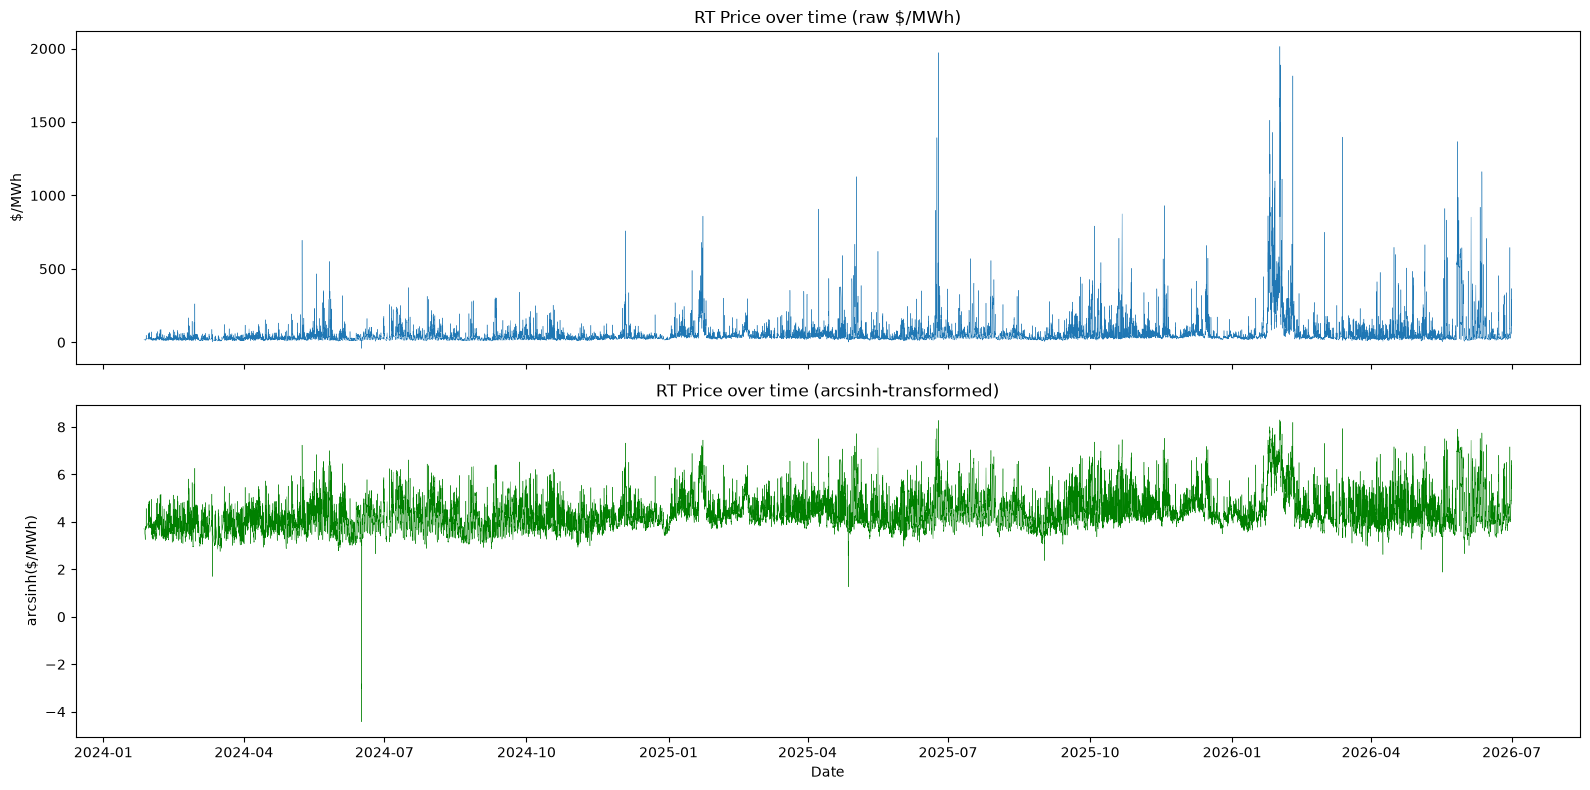

In [11]:
# Plotting target variable over time

df_sorted = df.sort_values('datetime_ept')

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df_sorted['datetime_ept'], df_sorted['total_lmp_rt'], linewidth=0.3)
axes[0].set_title('RT Price over time (raw $/MWh)')
axes[0].set_ylabel('$/MWh')

axes[1].plot(df_sorted['datetime_ept'], df_sorted['arcsinh_total_lmp_rt'], linewidth=0.3, color='green')
axes[1].set_title('RT Price over time (arcsinh-transformed)')
axes[1].set_ylabel('arcsinh($/MWh)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

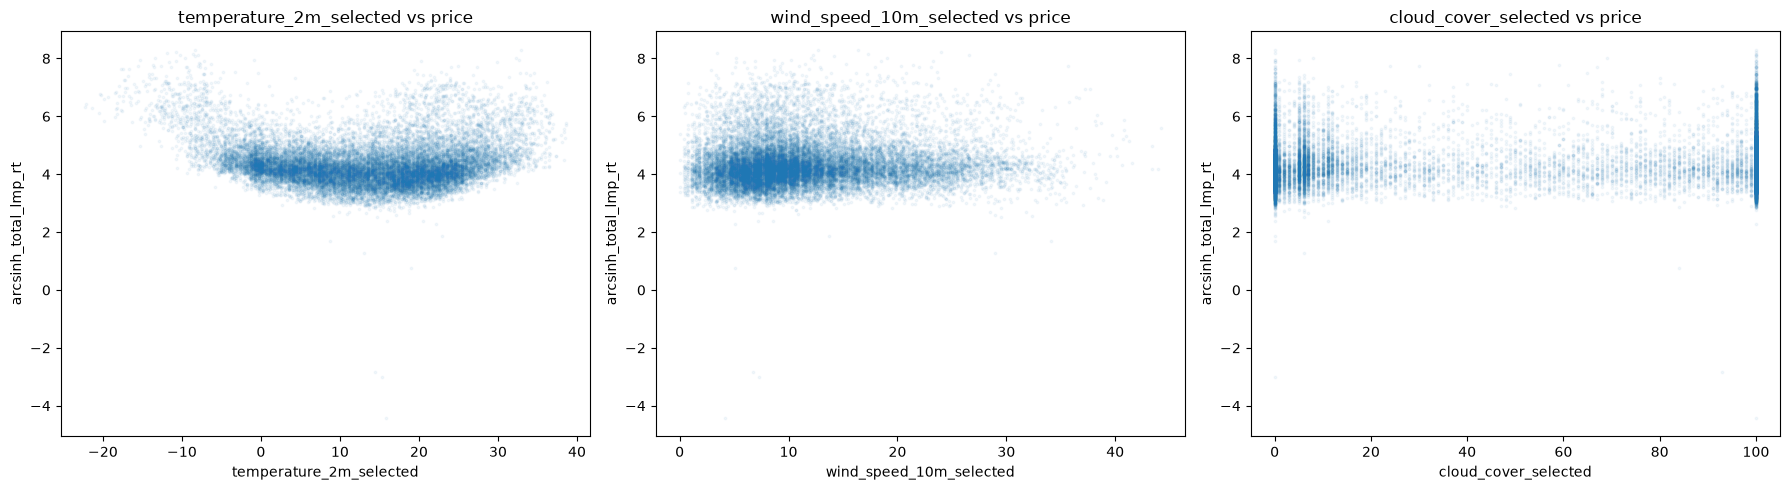

In [12]:
# Plotting weather variables vs target variable

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

weather_cols = ['temperature_2m_selected', 'wind_speed_10m_selected', 'cloud_cover_selected']

for ax, col in zip(axes, weather_cols):
    ax.scatter(df[col], df['arcsinh_total_lmp_rt'], alpha=0.05, s=3)
    ax.set_xlabel(col)
    ax.set_ylabel('arcsinh_total_lmp_rt')
    ax.set_title(f'{col} vs price')

plt.tight_layout()
plt.show()

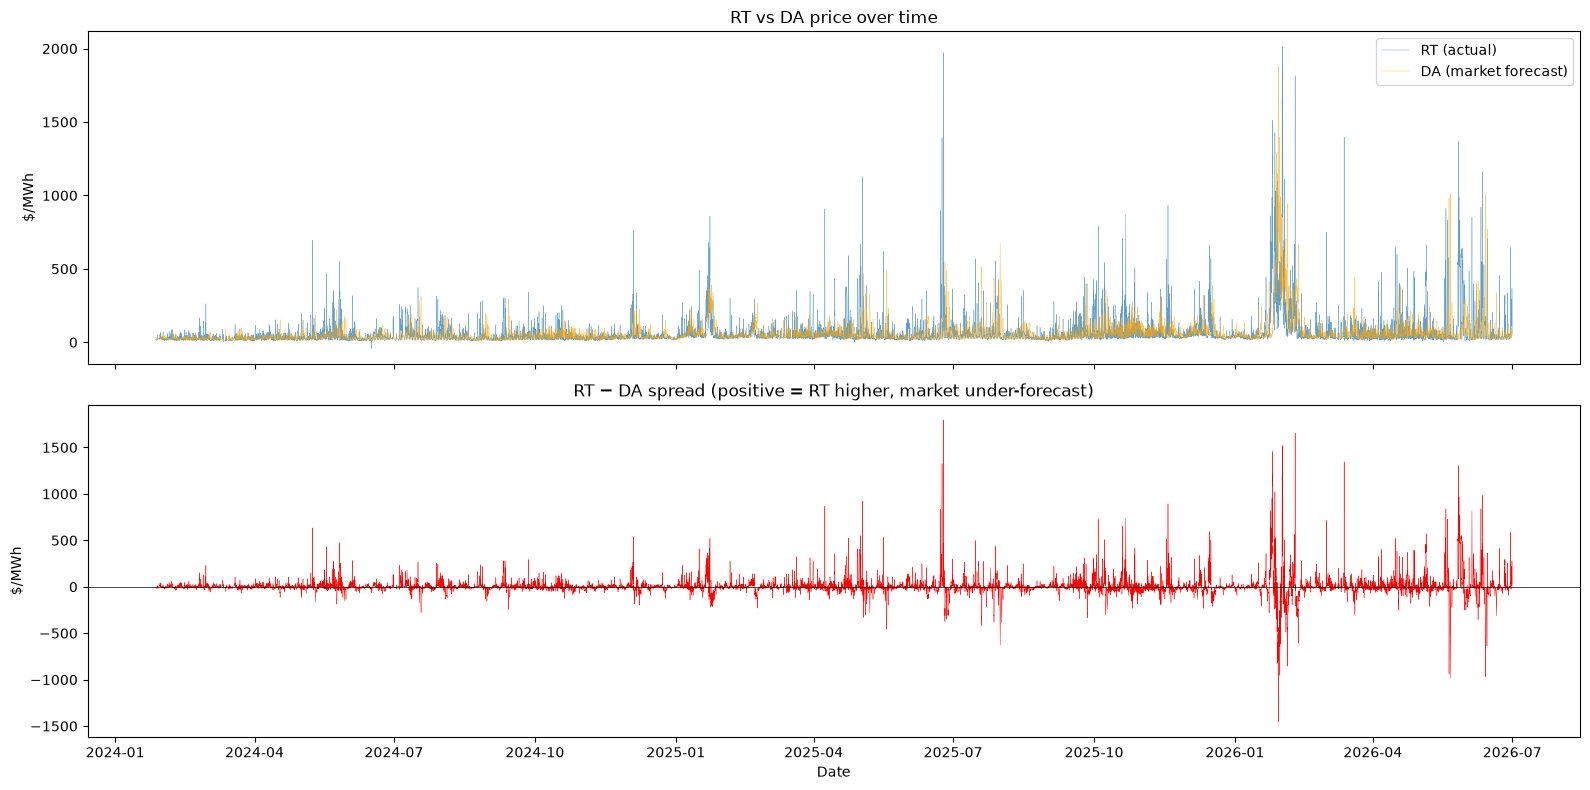

In [13]:
# RT vs DA comparison

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Overlay RT and DA prices
axes[0].plot(df_sorted['datetime_ept'], df_sorted['total_lmp_rt'], linewidth=0.3, label='RT (actual)', alpha=0.7)
axes[0].plot(df_sorted['datetime_ept'], df_sorted['lagged_lmp_da_1'], linewidth=0.3, label='DA (market forecast)', alpha=0.7, color='orange')
axes[0].set_title('RT vs DA price over time')
axes[0].set_ylabel('$/MWh')
axes[0].legend()

# The spread between them
spread = df_sorted['total_lmp_rt'] - df_sorted['lagged_lmp_da_1']
axes[1].plot(df_sorted['datetime_ept'], spread, linewidth=0.3, color='red')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('RT − DA spread (positive = RT higher, market under-forecast)')
axes[1].set_ylabel('$/MWh')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

## LightGBM Baseline on Expanding Window

In [14]:
# Unique month-year combinations
df_sorted['datetime_month_ept'] = df_sorted['datetime_ept'].dt.to_period('M')

# Unique month list
unique_months = sorted(df_sorted['datetime_month_ept'].unique())
print(unique_months)

[Period('2024-01', 'M'), Period('2024-02', 'M'), Period('2024-03', 'M'), Period('2024-04', 'M'), Period('2024-05', 'M'), Period('2024-06', 'M'), Period('2024-07', 'M'), Period('2024-08', 'M'), Period('2024-09', 'M'), Period('2024-10', 'M'), Period('2024-11', 'M'), Period('2024-12', 'M'), Period('2025-01', 'M'), Period('2025-02', 'M'), Period('2025-03', 'M'), Period('2025-04', 'M'), Period('2025-05', 'M'), Period('2025-06', 'M'), Period('2025-07', 'M'), Period('2025-08', 'M'), Period('2025-09', 'M'), Period('2025-10', 'M'), Period('2025-11', 'M'), Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M'), Period('2026-05', 'M'), Period('2026-06', 'M')]


In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# Using cross-validation for hyperparameter tuning across each window

def ExpandingWindowCV(train_months_list, df_sorted, feature_cols, target_col, param_grid, min_train_months=2):
    """
    Expanding-window cross-validation: for each hyperparameter combination, averaging its MAE across all monthly folds. 
    Returning the best combo.
    """

    best_score = float('inf') # Infinity so that first score is always starts lower in the loop
    best_params = None
    all_results = []

    for idx, params in enumerate(param_grid):
        fold_scores = []

        # Looping through months

        for j in range(min_train_months, len(train_months_list)):
            inner_train_months = train_months_list[:j]
            inner_val_month = train_months_list[j]

            # Filtering for necessary months using a boolean mask
            inner_train_mask = df_sorted['datetime_month_ept'].isin(inner_train_months)
            inner_val_mask = df_sorted['datetime_month_ept'] == inner_val_month

            # Creating train and val sets
            X_train = df_sorted.loc[inner_train_mask, feature_cols]
            y_train = df_sorted.loc[inner_train_mask, target_col]
            X_val = df_sorted.loc[inner_val_mask, feature_cols]
            y_val_raw = df_sorted.loc[inner_val_mask, 'total_lmp_rt']

            # Instantiating LGBM model
            model = lgb.LGBMRegressor(**params, random_state = 42, verbosity = -1, n_jobs = -1)
            model.fit(X_train, y_train)

            y_pred = model.predict(X_val) # Making predictions for this fold
            y_preds_raw = np.sinh(y_pred) # Converting back to raw units for interpretable comparison


            fold_scores.append(mean_absolute_error(y_val_raw, y_preds_raw))

        avg_score = np.mean(fold_scores) # Taking mean of fold scores
        all_results.append({**params, 'avg_mae': avg_score}) # List with all results

        # Printing progress every 50 iterations
        if idx % 50 == 0:
            print(f"[{idx}/{len(param_grid)}] this combo: {params} -> ${avg_score:.2f}")


        # Keeping track of best seen params
        if avg_score < best_score:
                best_score = avg_score
                best_params = params
             
    # Dataframe with all results saved to CSV file
    pd.DataFrame(all_results).to_csv('../../data/lgbm_cv_results.csv', index=False)

    return best_params, best_score, all_results

In [ ]:
from itertools import product

# Defining features
feature_cols = [c for c in df_sorted.columns if c not in ['total_lmp_rt', 'arcsinh_total_lmp_rt', 'datetime_ept', 'datetime_month_ept']]

# Defining target
target_col = 'arcsinh_total_lmp_rt'

min_train_months = 3

# Param grid to search earch through for optimal hyperparameters

base_dict = { 
    'n_estimators': [100, 200], 
    'learning_rate': [0.01, 0.05, 0.1], 
    'max_depth': [-1, 8],       
    'num_leaves': [20, 31, 50], 
    'reg_alpha': [0, 1], 
    'reg_lambda': [0, 1], 
} 

# Converting param dict to a list of dictionaries
base_keys = list(base_dict.keys()) 
base_combos = [dict(zip(base_keys, combo)) for combo in product(*base_dict.values())] 

# Adding different loss functions to the param grid with a range of alpha values for combinations involving Huber loss
param_grid = [] 
for combo in base_combos: 
    param_grid.append({**combo, 'objective': 'mae'}) 
    param_grid.append({**combo, 'objective': 'mse'}) 
    for a in [0.1, 0.5, 0.9]: 
        param_grid.append({**combo, 'objective': 'huber', 'alpha': a}) 

cv_results = []

# Calling CV function
best_params, best_score, all_results = ExpandingWindowCV(
    train_months_list=unique_months,
    df_sorted=df_sorted,   
    feature_cols=feature_cols,
    target_col=target_col,
    param_grid=param_grid,
    min_train_months=3
)

print(f"Best params: {best_params}")
print(f"Best avg MAE: ${best_score:.2f}")


[0/720] this combo: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': -1, 'num_leaves': 20, 'reg_alpha': 0, 'reg_lambda': 0, 'objective': 'mae'} -> $33.13
[50/720] this combo: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': -1, 'num_leaves': 50, 'reg_alpha': 1, 'reg_lambda': 0, 'objective': 'mae'} -> $32.94
[100/720] this combo: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 8, 'num_leaves': 50, 'reg_alpha': 0, 'reg_lambda': 0, 'objective': 'mae'} -> $32.91
[150/720] this combo: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': -1, 'num_leaves': 31, 'reg_alpha': 1, 'reg_lambda': 0, 'objective': 'mae'} -> $29.85
[200/720] this combo: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 8, 'num_leaves': 31, 'reg_alpha': 0, 'reg_lambda': 0, 'objective': 'mae'} -> $29.82
[250/720] this combo: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': -1, 'num_leaves': 20, 'reg_alpha': 1, 'reg_lambda': 0, 'objective': 'mae'} -> $29.48
[300/720] this c

## Model Comparison

In [15]:
import lightgbm as lgb
# Looping through the 27 folds using the best parameters to compute hourly mae for direct comparison with DA

hourly_predictions = []

# Defining features
feature_cols = [c for c in df_sorted.columns if c not in ['total_lmp_rt', 'arcsinh_total_lmp_rt', 'datetime_ept', 'datetime_month_ept']]

# Defining target
target_col = 'arcsinh_total_lmp_rt'

# Best hyperparameters from previous run
best_params = {
    'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': -1,
    'num_leaves': 50, 'reg_alpha': 0, 'reg_lambda': 0,
    'objective': 'huber', 'alpha': 0.5
}

# Looping though months same as before
for j in range(3, len(unique_months)):
    
    # Defining train and val months
    model_train_months = unique_months[:j]
    model_val_months = unique_months[j]

    model_train_mask = df_sorted['datetime_month_ept'].isin(model_train_months)
    model_val_mask = df_sorted['datetime_month_ept'] == model_val_months

    # Defining train and validation data
    X_train_model = df_sorted.loc[model_train_mask, feature_cols]
    X_val_model = df_sorted.loc[model_val_mask, feature_cols]
    y_train_model = df_sorted.loc[model_train_mask, target_col]
    y_val_model_raw = df_sorted.loc[model_val_mask, 'total_lmp_rt']

    # Instantiating model wiht best parameters from previous run
    best_model = lgb.LGBMRegressor(
        **best_params,
        random_state = 42,
        n_jobs = -1,
        verbosity = -1
    )

    # Fitting and making predictions
    best_model.fit(X_train_model, y_train_model)

    y_pred_model = best_model.predict(X_val_model)
    y_pred_model_raw = np.sinh(y_pred_model)

    # Taking hourly datetime values and forming a df
    val_datetimes = df_sorted.loc[model_val_mask, 'datetime_ept']

    best_model_df = pd.DataFrame({
        'datetime_ept': val_datetimes,
        'actual_rt': y_val_model_raw.values,
        'prediction': y_pred_model_raw,
    })

    hourly_predictions.append(best_model_df)

all_predictions = pd.concat(hourly_predictions, ignore_index = True)
all_predictions.to_csv('../../data/best_model_hourly_predictions.csv', index=False)


In [16]:
# Loading hourly predictions 

hourly = pd.read_csv('../../data/best_model_hourly_predictions.csv')
hourly.head()



,datetime_ept,actual_rt,prediction
0,2024-04-01 00:00:00,15.900472,13.689728
1,2024-04-01 01:00:00,12.229219,14.142949
2,2024-04-01 02:00:00,12.506178,13.235347
3,2024-04-01 03:00:00,10.764200,14.080382
4,2024-04-01 04:00:00,11.228077,15.672380


In [17]:
# Creating absolute value difference column to later compare with DA

hourly['model_abs_diff'] = np.abs(hourly['actual_rt'] - hourly['prediction'])

hourly.head()

,datetime_ept,actual_rt,prediction,model_abs_diff
0,2024-04-01 00:00:00,15.900472,13.689728,2.210744
1,2024-04-01 01:00:00,12.229219,14.142949,1.913730
2,2024-04-01 02:00:00,12.506178,13.235347,0.729169
3,2024-04-01 03:00:00,10.764200,14.080382,3.316182
4,2024-04-01 04:00:00,11.228077,15.672380,4.444303


In [18]:
# Loading DA hourly data and adding it as a column in hourly 

import duckdb

con = duckdb.connect()

# Loading timestamp and day ahead total lmp prediction and converting to df
da_actual = con.sql("""
    SELECT
        CAST(datetime_beginning_ept AS TIMESTAMP) AS datetime_ept,
        total_lmp_da AS da_pred
    FROM '../../data/rt_da_*.parquet'
""").df()

# Ensuring correct datetime formats
hourly['datetime_ept'] = pd.to_datetime(hourly['datetime_ept'])
da_actual['datetime_ept'] = pd.to_datetime(da_actual['datetime_ept'])

# Using left join to ensure no nulls
hourly = hourly.merge(da_actual, on = 'datetime_ept', how = 'left')
print(hourly.isna().any().any())
hourly





False


,datetime_ept,actual_rt,prediction,model_abs_diff,da_pred
0,2024-04-01 00:00:00,15.900472,13.689728,2.210744,14.370399
1,2024-04-01 01:00:00,12.229219,14.142949,1.913730,12.725088
2,2024-04-01 02:00:00,12.506178,13.235347,0.729169,13.010622
3,2024-04-01 03:00:00,10.764200,14.080382,3.316182,12.985443
4,2024-04-01 04:00:00,11.228077,15.672380,4.444303,13.846278
...,...,...,...,...,...
19394,2026-06-30 19:00:00,268.421072,152.808170,115.612902,293.410000
19395,2026-06-30 20:00:00,366.027805,112.167236,253.860569,218.356262
19396,2026-06-30 21:00:00,160.871674,92.945719,67.925955,109.234351
19397,2026-06-30 22:00:00,80.398856,63.615296,16.783560,82.531892


In [19]:
# DA absolute difference hourly

hourly['da_abs_diff'] = np.abs(hourly['actual_rt'] - hourly['da_pred'])
hourly.head()

,datetime_ept,actual_rt,prediction,model_abs_diff,da_pred,da_abs_diff
0,2024-04-01 00:00:00,15.900472,13.689728,2.210744,14.370399,1.530073
1,2024-04-01 01:00:00,12.229219,14.142949,1.913730,12.725088,0.495869
2,2024-04-01 02:00:00,12.506178,13.235347,0.729169,13.010622,0.504444
3,2024-04-01 03:00:00,10.764200,14.080382,3.316182,12.985443,2.221243
4,2024-04-01 04:00:00,11.228077,15.672380,4.444303,13.846278,2.618201


In [23]:
# Calculating the rate at which my model outperforms the da prediction on validation data

hourly['model_win'] = hourly['model_abs_diff'] < hourly['da_abs_diff']
win_rate  = hourly['model_win'].mean()

print(f"Validation Win rate: {win_rate:.2%}")
print(f"LGBM Validation MAE: ${hourly['model_abs_diff'].mean():.2f}")
print(f"DA Validation MAE: ${hourly['da_abs_diff'].mean():.2f}")

Validation Win rate: 41.56%
LGBM Validation MAE: $29.42
DA Validation MAE: $26.51


In [24]:
# Calculating monthly win rate 

hourly['month'] = hourly['datetime_ept'].dt.to_period('M').astype(str)

monthly = hourly.groupby('month', as_index = False).agg(
    model_mae = ('model_abs_diff', 'mean'),
    da_mae = ('da_abs_diff', 'mean'),
    win_rate = ('model_win', 'mean'),
    num_hours = ('model_win', 'count')
)

monthly['gap'] = monthly['model_mae'] - monthly['da_mae']

monthly

,month,model_mae,da_mae,win_rate,num_hours,gap
0,2024-04,12.235449,10.659090,0.413889,720,1.576359
1,2024-05,23.907455,21.548568,0.454301,744,2.358887
2,2024-06,15.130997,9.958829,0.242816,696,5.172168
3,2024-07,22.420085,16.533113,0.346726,672,5.886972
4,2024-08,12.550694,11.449534,0.444892,744,1.101159
5,2024-09,15.932243,12.329564,0.295833,720,3.602679
6,2024-10,12.917367,13.308238,0.544355,744,-0.390872
7,2024-11,8.047638,7.175042,0.421199,717,0.872595
8,2024-12,13.997883,14.001351,0.446237,744,-0.003468
9,2025-01,34.750990,29.107805,0.393817,744,5.643185


/var/folders/13/k24lx27s73b3kcpyzkbc83vc0000gn/T/ipykernel_55965/2149301236.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(monthly['month'], rotation=45, ha='right')


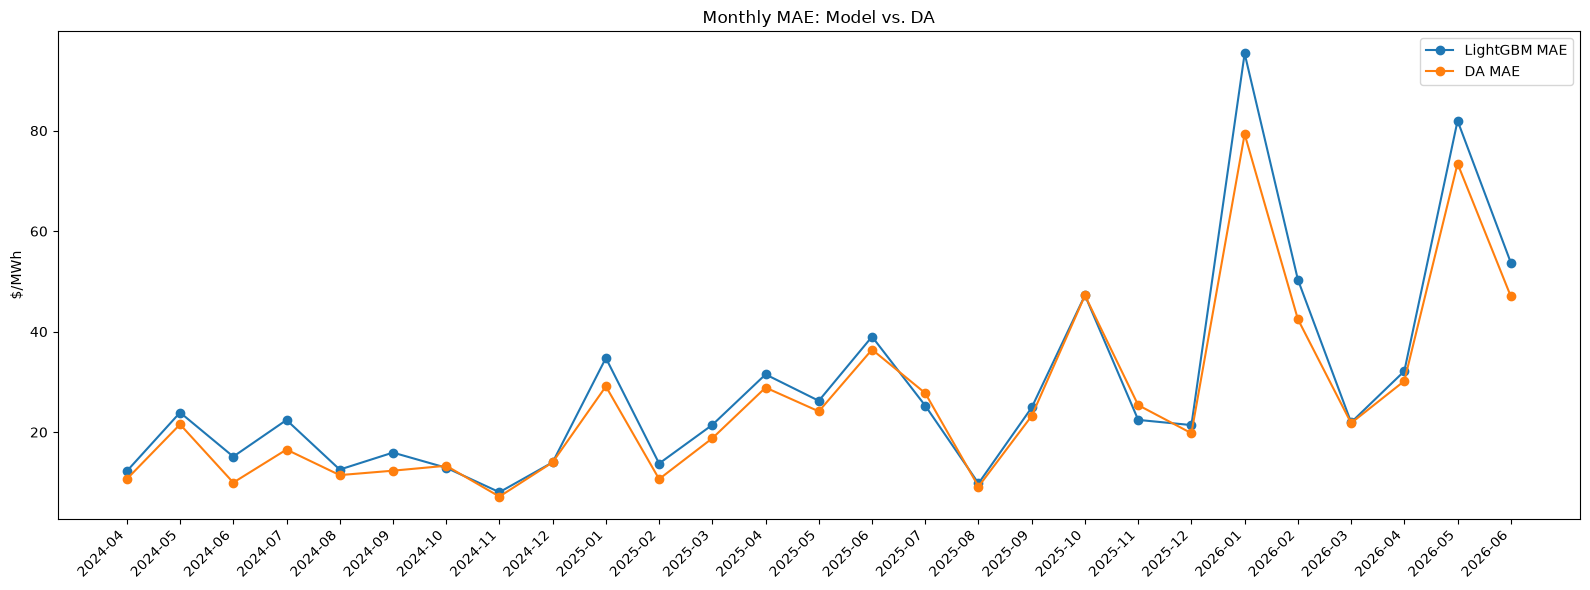

In [25]:
# Plotting mae for model predictions and DA predictions over time to see if they have similar spikes
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(monthly['month'], monthly['model_mae'], marker='o', label='LightGBM MAE')
ax.plot(monthly['month'], monthly['da_mae'], marker='o', label='DA MAE')

ax.set_xticklabels(monthly['month'], rotation=45, ha='right')
ax.set_ylabel('$/MWh')
ax.set_title('Monthly MAE: Model vs. DA')
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
# Naive baseline comparison (comparing model predictions vs yesterday at this time and last week on this day at this time)

naive = hourly.merge(df_sorted[['datetime_ept', 'lagged_lmp_rt_1', 'lagged_lmp_rt_7']], on = 'datetime_ept', how = 'left')

naive['yesterday_abs_diff'] = np.abs(naive['actual_rt'] - naive['lagged_lmp_rt_1'])
naive['lastweek_abs_diff'] = np.abs(naive['actual_rt'] - naive['lagged_lmp_rt_7'])

print(f"Day before prediction MAE: ${naive['yesterday_abs_diff'].mean():.2f}")
print(f"One week before prediction: ${naive['lastweek_abs_diff'].mean():.2f}")
print(f"LGBM MAE: ${hourly['model_abs_diff'].mean():.2f}")

Day before prediction MAE: $43.52
One week before prediction: $48.91
LGBM MAE: $29.42


## Final Model Training

In [16]:
import lightgbm as lgb
# Training final model for deployment

best_params = {
    'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': -1,
    'num_leaves': 50, 'reg_alpha': 0, 'reg_lambda': 0,
    'objective': 'huber', 'alpha': 0.5
}

# Defining final predictor and target variables
final_features = [col for col in df_sorted.columns if col not in ['total_lmp_rt', 'arcsinh_total_lmp_rt', 'datetime_ept', 'datetime_month_ept']]

X = df_sorted[final_features]
y = df_sorted['arcsinh_total_lmp_rt']

# Fitting final model
final_model = lgb.LGBMRegressor(**best_params, random_state = 42)
final_model.fit(X, y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13064
[LightGBM] [Info] Number of data points in the train set: 20815, number of used features: 74
[LightGBM] [Info] Start training from score 4.352338


,num_leaves,50
,learning_rate,0.05
,n_estimators,200
,objective,'huber'
,random_state,42
,alpha,0.5
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0


In [20]:
from sklearn.metrics import mean_absolute_error
# Evaluating final model training MAE
train_preds_raw = np.sinh(final_model.predict(X))
train_mae = mean_absolute_error(df_sorted['total_lmp_rt'], train_preds_raw)
print(f"Train MAE: ${train_mae:.2f}")

Train MAE: $17.75


In [18]:
# Final model feature importances

feature_importances = pd.DataFrame({
    'feature': final_features,
    'importance': final_model.feature_importances_
}).sort_values(by = 'importance', ascending = False)

print(feature_importances.head(30))

                                 feature  importance
8                       forecast_load_mw         684
5                temperature_2m_selected         524
39                    lagged_gas_price_1         490
40                    lagged_gas_price_3         465
41                    lagged_gas_price_7         403
0                                  month         333
1                            day_of_week         216
44              lagged_coal_percentage_7         210
43              lagged_coal_percentage_3         202
36       lagged_marginal_loss_price_da_1         193
42              lagged_coal_percentage_1         189
52    lagged_multiple_fuels_percentage_3         184
46               lagged_gas_percentage_3         182
2                            hour_of_day         182
7                   cloud_cover_selected         177
45               lagged_gas_percentage_1         172
65             lagged_solar_percentage_7         161
66              lagged_wind_percentage_1      

## Pickling the Original Baseline Model

In [21]:
import pickle

# Storing baseline model as lgbm_v1
with open('../../models/lgbm_v1.pkl', 'wb') as v1_model:
    pickle.dump(final_model, v1_model)

# Metadata from baseline model
metadata = {
    'feature_cols': final_features,
    'best_params': best_params,
    'target_transform': 'arcsinh',
    'inverse_transform': 'np.sinh',
    'validation_mae': 29.42,
    'da_benchmark_mae': 26.51,
    'win_rate_vs_da': 0.4156,
}

with open('../../models/lgbm_v1_metadata.pkl', 'wb') as v1_metadata:
    pickle.dump(metadata, v1_metadata)

print("Model and metadata saved")

Model and metadata saved
